In [1]:
!pip install numpy pandas torch scikit-learn tensorflow deepctr-torch

In [2]:
#################################
# Import Libraries
#################################
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import LabelEncoder
from deepctr_torch.inputs import SparseFeat, get_feature_names
from deepctr_torch.models import DeepFM
import matplotlib.pyplot as plt
from driftwatch.embedding_tracker import EmbeddingTracker

In [3]:
#################################
# Load and Preprocess Data
#################################
# Load and preprocess data
data = pd.read_json("Amazon_Fashion.jsonl", lines=True)
data = data[data["rating"] != 3]
data = data[data["timestamp"] > '2015-01-01']
data["year"] = data["timestamp"].apply(lambda x: x.year)
data["month"] = data["timestamp"].apply(lambda x: x.month)
data["day"] = data["timestamp"].apply(lambda x: x.day)
data["rating"] = data["rating"].transform(lambda x: 1 if x > 3 else 0)


# print length of data
print(len(data))

# Set index to timestamp
data = data.set_index("timestamp")
data.sort_index(inplace=True)

2166931


/var/folders/2l/zhq3rqwj4_lg1b9s5c1yjqf00000gp/T/ipykernel_44993/2072501785.py:51: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/jasper.bruin/miniconda3/envs/driftwatch-new/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


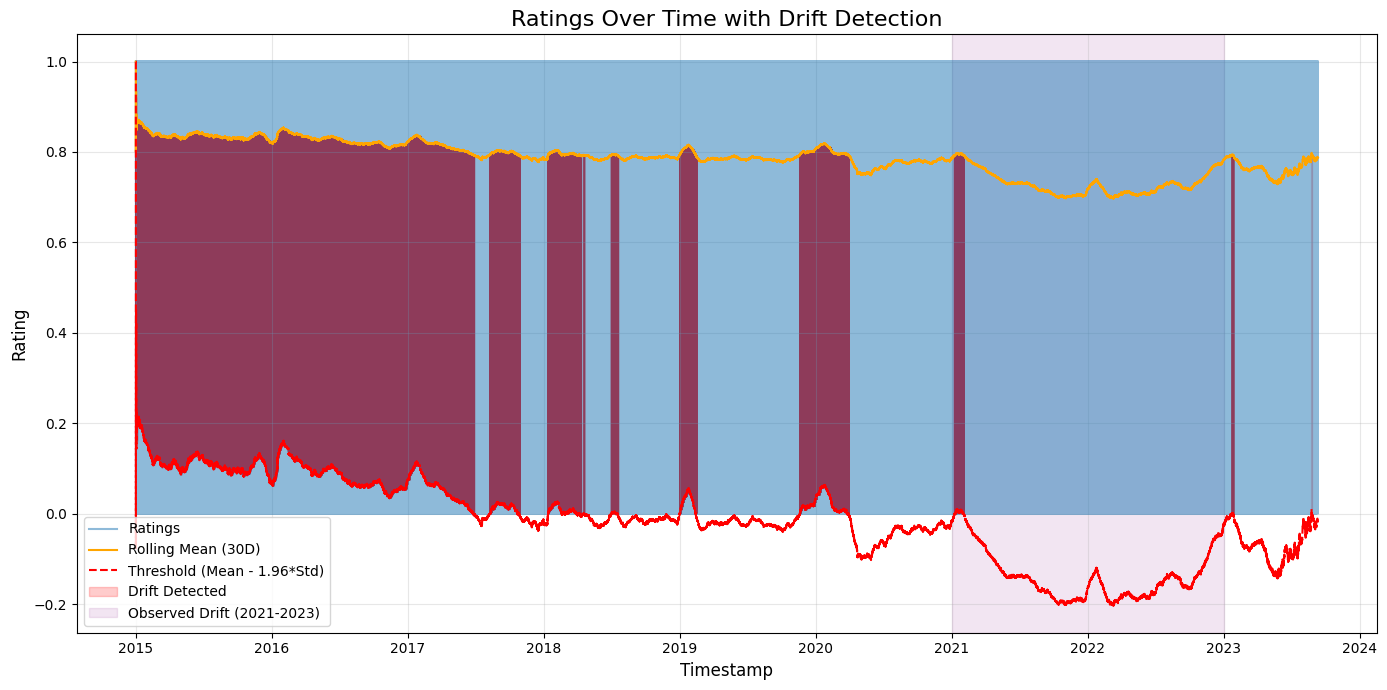

In [4]:
#################################
# Define Ground Truth Functionality
#################################
# Calculate rolling mean and threshold
rolling_mean = data["rating"].rolling("30D").mean()
rolling_std = data["rating"].rolling("30D").std()
significance_threshold = rolling_mean - 1.96 * rolling_std

# Add ground truth drift flag based on threshold
data["drift_flag"] = (data["rating"] < significance_threshold).fillna(False)


#################################
# Visualize Data and Mark Observed Drift
#################################
plt.figure(figsize=(14, 7))

# Plot ratings over time
plt.plot(data.index, data["rating"], label="Ratings", alpha=0.5)
# Plot rolling mean
plt.plot(data.index, rolling_mean, label="Rolling Mean (30D)", color="orange")
# Plot significance threshold
plt.plot(data.index, significance_threshold, label="Threshold (Mean - 1.96*Std)", color="red", linestyle="--")

# Highlight drift periods
plt.fill_between(
    data.index,
    rolling_mean,
    significance_threshold,
    where=data["drift_flag"],
    color="red",
    alpha=0.2,
    label="Drift Detected",
)

# Highlight observed drift (2021–2023)
plt.axvspan(
    pd.Timestamp("2021-01-01"), 
    pd.Timestamp("2023-01-01"), 
    color="purple", 
    alpha=0.1, 
    label="Observed Drift (2021-2023)"
)

# Add titles and legend
plt.title("Ratings Over Time with Drift Detection", fontsize=16)
plt.xlabel("Timestamp", fontsize=12)
plt.ylabel("Rating", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [5]:
# print data features
print("Data Features:" + str(data.columns))

print(f"length of data: {len(data)}")

sparse_features = ["asin", "parent_asin", "user_id"]
target = "rating"

print("data_flag: " + str(data["drift_flag"].value_counts()))
# 
# print(data["asin"].nunique())  # Should show high cardinality
# print(data["user_id"].nunique())  # Should show high cardinality

print("asin: " + str(data["asin"].nunique()))
print("user_id: " + str(data["user_id"].nunique()))


Data Features:Index(['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id',
       'helpful_vote', 'verified_purchase', 'year', 'month', 'day',
       'drift_flag'],
      dtype='object')
length of data: 2166931
data_flag: drift_flag
False    2000489
True      166442
Name: count, dtype: int64
asin: 798541
user_id: 1795694


In [ ]:
## use embedding tracker here

#################################
# Model Training (DeepFM)
#################################
# Label encoding
for feat in sparse_features:
    lbe = LabelEncoder()
    data[feat] = lbe.fit_transform(data[feat])

# Define feature columns
embedding_dim = 64
fixlen_feature_columns = [
    SparseFeat(feat, data[feat].nunique(), embedding_dim=embedding_dim)
    for feat in sparse_features
]
linear_feature_columns = fixlen_feature_columns
dnn_feature_columns = fixlen_feature_columns
feature_names = get_feature_names(linear_feature_columns + dnn_feature_columns)

# Prepare model input
model_input = {name: data[name] for name in sparse_features}

# Decide on device
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
    
model = DeepFM(linear_feature_columns, dnn_feature_columns, task='binary', device=device)
model.compile("adam", metrics=["AUC"], loss='binary_crossentropy')

# Train the model (using some fraction of data as data_sample)
data_sample = data.sample(frac=1.0, random_state=42)  # example sampling
history = model.fit(
    {name: data_sample[name] for name in sparse_features},
    data_sample[target].values,
    batch_size=1024,
    epochs=2,
    verbose=2,
    validation_split=0.1
)

mps
Train on 1950237 samples, validate on 216694 samples, 1905 steps per epoch


In [ ]:
import numpy as np
import torch
from sklearn.metrics import confusion_matrix

#################################
# Embedding Tracker Setup for Drift Detection
#################################
window_size = 50
threshold_multiplier = 3.0
alpha = 0.01

# Initialize the embedding tracker
embedding_tracker = EmbeddingTracker(
    embedding_dim=embedding_dim * len(sparse_features),  # Account for all features, not just one
    alpha=alpha,
    distance_name="mahalanobis"  # Using Mahalanobis distance
)

drift_distances = []
thresholds = []
predicted_drift_labels = []

# To map each batch back to its ground truth drift label, we need indexing:
n_batches = 300
batch_list = np.array_split(data_sample, n_batches)

# First, establish baseline distribution using initial batches (first 30% of batches)
baseline_batches = int(n_batches * 0.3)
print(f"Using first {baseline_batches} batches to establish baseline distribution")

# Extract actual embeddings from the DeepFM model
def get_embeddings(model, batch_input):
    """Extract actual embeddings from model's embedding layers"""
    # Run the input through the model to prepare embeddings
    _ = model.predict(batch_input)
    # Extract embeddings from the model's embedding layers
    embeddings = []
    for feat in sparse_features:
        # Get the embedding from the model's feature embedding dictionary
        feat_emb = model.embedding_dict[feat].weight.detach().cpu().numpy()
        # Get the indices from the batch input
        indices = batch_input[feat]
        # Get the actual embeddings for these indices
        batch_feat_emb = feat_emb[indices]
        embeddings.append(batch_feat_emb)
    # Concatenate all embeddings
    return np.concatenate(embeddings, axis=1)

baseline_distances = []

with torch.no_grad():
    # Train baseline distribution
    for batch_index in range(baseline_batches):
        batch_df = batch_list[batch_index]
        # Prepare batch input
        batch_input = {key: batch_df[key].values for key in sparse_features}
        
        # Get model's actual embeddings
        embeddings = get_embeddings(model, batch_input)
        mean_embedding = np.mean(embeddings, axis=0)
        
        # Update the embedding tracker with baseline data
        embedding_tracker.update(mean_embedding)
        
        # Also compute distance for the baseline samples (for consistent visualization)
        if batch_index > 0:  # Skip first batch as we just initialized with it
            drift_distance = embedding_tracker.compute_distance(mean_embedding)
            baseline_distances.append(drift_distance)
    
    # Calculate initial threshold from baseline distances
    initial_threshold = (
        np.mean(baseline_distances) + 
        threshold_multiplier * np.std(baseline_distances)
    )
    
    # Store baseline distances and thresholds for visualization
    drift_distances.extend(baseline_distances)
    thresholds.extend([initial_threshold] * len(baseline_distances))
    # Baseline batches are assumed non-drift by definition
    predicted_drift_labels.extend([0] * len(baseline_distances))
    
    print("Baseline distribution established")
    
    # Now detect drift in all batches
    for batch_index in range(baseline_batches, n_batches):
        batch_df = batch_list[batch_index]
        # Prepare batch input
        batch_input = {key: batch_df[key].values for key in sparse_features}
        
        # Get model's actual embeddings
        embeddings = get_embeddings(model, batch_input)
        mean_embedding = np.mean(embeddings, axis=0)
        
        # Compute drift distance
        drift_distance = embedding_tracker.compute_distance(mean_embedding)
        drift_distances.append(drift_distance)
        
        # Dynamic threshold using rolling window
        if len(drift_distances) > window_size:
            recent_dists = drift_distances[-window_size:]
            mean_dist = np.mean(recent_dists)
            std_dist = np.std(recent_dists)
            threshold = mean_dist + threshold_multiplier * std_dist
        else:
            threshold = initial_threshold
        
        thresholds.append(threshold)
        
        # Predicted drift (batch level)
        if drift_distance > threshold:
            predicted_drift_labels.append(1)
        else:
            predicted_drift_labels.append(0)
            # Optional: Only update tracker on non-drift samples (adaptive tracking)
            # embedding_tracker.update(mean_embedding)

        # If drift is detected
        if predicted_drift_labels[-1] == 1:
            print(f"Batch {batch_index}: Drift detected! Distance = {drift_distance:.4f}, Threshold = {threshold:.4f}")

# Visualization of drift distances and thresholds
plt.figure(figsize=(14, 7))
plt.plot(drift_distances, label="Drift Distance")
plt.plot(thresholds, label="Threshold")
plt.title("Embedding Tracker Drift Detection")
plt.xlabel("Batch Index")
plt.ylabel("Distance")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Visualize drift over time with original data timestamps
plt.figure(figsize=(14, 7))

# Get the timestamps from batch_list
batch_timestamps = [batch_df.index.mean() for batch_df in batch_list]

# Plot drift scores over time
plt.plot(batch_timestamps, drift_distances, label="Drift Score", color="blue")
plt.plot(batch_timestamps, thresholds, label="Threshold", color="red", linestyle="--")

# Highlight drift periods
drift_indices = [i for i, label in enumerate(predicted_drift_labels) if label == 1]
if drift_indices:
    drift_timestamps = [batch_timestamps[i] for i in drift_indices]
    drift_scores = [drift_distances[i] for i in drift_indices]
    plt.scatter(drift_timestamps, drift_scores, color="red", s=50, label="Detected Drift")

# Highlight observed drift (2021–2023)
plt.axvspan(
    pd.Timestamp("2021-01-01"), 
    pd.Timestamp("2023-01-01"), 
    color="purple", 
    alpha=0.1, 
    label="Observed Drift (2021-2023)"
)

plt.title("Drift Scores Over Time", fontsize=16)
plt.xlabel("Time", fontsize=12)
plt.ylabel("Drift Score", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
#################################
# Compute Ground Truth (Batch-Level) and FPR
#################################
# Ground truth drift label per batch: >X% drift_flag -> drift
# This is based on the imbalance observed in the drift_flag feature.
actual_drift_labels = []
for i, batch_df in enumerate(batch_list):
    batch_flags = batch_df["drift_flag"]
    drift_fraction = batch_flags.mean()
    label = 1 if drift_fraction > 0.06 else 0
    actual_drift_labels.append(label)

# Convert to numpy arrays
y_true = np.array(actual_drift_labels)
y_pred = np.array(predicted_drift_labels)

# Debugging: Check if lengths match
assert len(y_true) == len(y_pred), f"y_true and y_pred lengths do not match: {len(y_true)} vs {len(y_pred)}"

# Compute confusion matrix
tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

# Avoid division by zero in FPR calculation
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

# Print results
print("\nConfusion Matrix:")
print(f"  TP={tp}, FN={fn}, FP={fp}, TN={tn}")
print(f"False Positive Rate (FPR): {fpr:.4f}")

#################################
# Save Results
#################################
distances_path = "drift_distances_dl.npy"
thresholds_path = "drift_thresholds_dl.npy"
np.save(distances_path, drift_distances)
np.save(thresholds_path, thresholds)
print("\nDrift detection results saved.")